
Huấn luyện 3 mô hình (Random Forest, XGBoost, LightGBM) trên Dữ liệu Không Cân Bằng (Imbalanced Data).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, classification_report,
                             roc_curve, roc_auc_score, precision_recall_curve,
                             average_precision_score)

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

### 1. Load Data

In [2]:
df = pd.read_csv('creditcard_processed.csv')

# Formatting columns
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
df = df.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', x))

print(f"Data Shape: {df.shape}")
print("Class Distribution:\n", df['Class'].value_counts())

Data Shape: (283726, 31)
Class Distribution:
 Class
0    283253
1       473
Name: count, dtype: int64


### 2. Chia bộ dữ liệu (Train/Test Split)

In [3]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (226980, 30), y_train: (226980,)
X_test: (56746, 30), y_test: (56746,)


### Chuẩn hóa Dữ liệu (RobustScaler)
Thực hiện fit_transform trên tập Train và transform trên tập Test để tránh Data Leakage.

In [4]:
rob_scaler_amount = RobustScaler()
rob_scaler_time = RobustScaler()

# # Only fit on train set
X_train['scaled_amount'] = rob_scaler_amount.fit_transform(X_train['Amount'].values.reshape(-1,1))
X_train['scaled_time'] = rob_scaler_time.fit_transform(X_train['Time'].values.reshape(-1,1))

# Transform test set
X_test['scaled_amount'] = rob_scaler_amount.transform(X_test['Amount'].values.reshape(-1,1))
X_test['scaled_time'] = rob_scaler_time.transform(X_test['Time'].values.reshape(-1,1))

# Drop original columns
X_train.drop(['Time','Amount'], axis=1, inplace=True)
X_test.drop(['Time','Amount'], axis=1, inplace=True)

# Reorder columns
cols = ['scaled_amount', 'scaled_time'] + [c for c in X_train.columns if c not in ['scaled_amount', 'scaled_time']]
X_train = X_train[cols]
X_test = X_test[cols]   

print("X_train shape sau khi scale:", X_train.shape)
print("X_test shape sau khi scale:", X_test.shape)


global_results = []


X_train shape sau khi scale: (226980, 30)
X_test shape sau khi scale: (56746, 30)


### 4. Huấn luyện: Random Forest

=========== RANDOM FOREST ===========

---> Đang huấn luyện Random Forest trên Dữ liệu Không Cân Bằng <---
Training Time : 35.38 s
Accuracy      : 0.99954
Precision     : 0.98592
Recall        : 0.73684
F1-Score      : 0.84337
ROC-AUC       : 0.92438
PR-AUC        : 0.79798



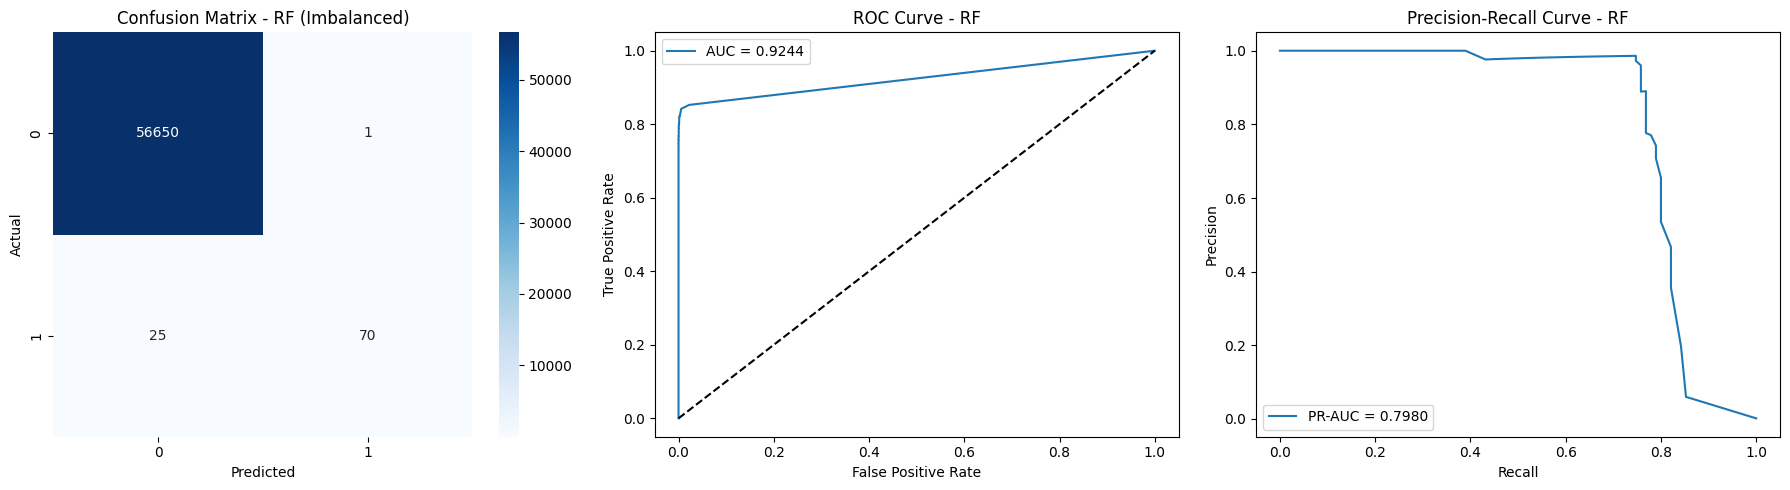

In [5]:
print("=========== RANDOM FOREST ===========\n")
print("---> Đang huấn luyện Random Forest trên Dữ liệu Không Cân Bằng <---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

start_time = time.time()
rf_model.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print(f"Training Time : {train_time:.2f} s")
print(f"Accuracy      : {accuracy_score(y_test, y_pred):.5f}")
print(f"Precision     : {precision_score(y_test, y_pred):.5f}")
print(f"Recall        : {recall_score(y_test, y_pred):.5f}")
print(f"F1-Score      : {f1_score(y_test, y_pred):.5f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, y_prob):.5f}")
print(f"PR-AUC        : {average_precision_score(y_test, y_prob):.5f}\n")

# Lưu kết quả
global_results.append({
    'Model': 'Random Forest',
    'Method': 'Imbalanced',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob),
    'PR-AUC': average_precision_score(y_test, y_prob),
    'Train_Time': train_time
})

# Plot CM, ROC, PR
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - RF (Imbalanced)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.4f}")
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve - RF')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[2].plot(rec, prec, label=f"PR-AUC = {average_precision_score(y_test, y_prob):.4f}")
axes[2].set_title('Precision-Recall Curve - RF')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()
plt.tight_layout()
plt.show()


### 5. Huấn luyện: XGBoost

=========== XGBOOST ===========

---> Đang huấn luyện XGBoost trên Dữ liệu Không Cân Bằng <---
Training Time : 1.10 s
Accuracy      : 0.99926
Precision     : 0.81176
Recall        : 0.72632
F1-Score      : 0.76667
ROC-AUC       : 0.93403
PR-AUC        : 0.74534



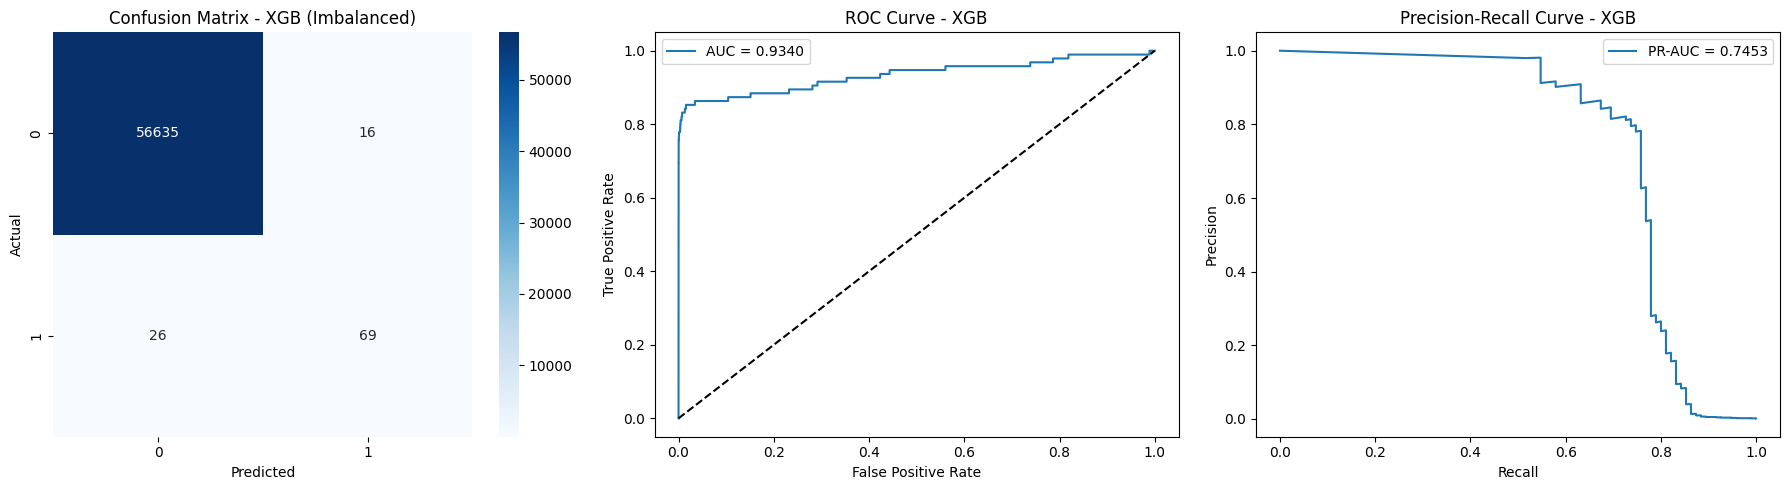

In [6]:
print("=========== XGBOOST ===========\n")
print("---> Đang huấn luyện XGBoost trên Dữ liệu Không Cân Bằng <---")
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

start_time = time.time()
xgb_model.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print(f"Training Time : {train_time:.2f} s")
print(f"Accuracy      : {accuracy_score(y_test, y_pred):.5f}")
print(f"Precision     : {precision_score(y_test, y_pred):.5f}")
print(f"Recall        : {recall_score(y_test, y_pred):.5f}")
print(f"F1-Score      : {f1_score(y_test, y_pred):.5f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, y_prob):.5f}")
print(f"PR-AUC        : {average_precision_score(y_test, y_prob):.5f}\n")

# Lưu kết quả
global_results.append({
    'Model': 'XGBoost',
    'Method': 'Imbalanced',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob),
    'PR-AUC': average_precision_score(y_test, y_prob),
    'Train_Time': train_time
})

# Plot CM, ROC, PR
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - XGB (Imbalanced)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.4f}")
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve - XGB')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[2].plot(rec, prec, label=f"PR-AUC = {average_precision_score(y_test, y_prob):.4f}")
axes[2].set_title('Precision-Recall Curve - XGB')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()
plt.tight_layout()
plt.show()


### 6. Huấn luyện: LightGBM

=========== LIGHTGBM ===========

---> Đang huấn luyện LightGBM trên Dữ liệu Không Cân Bằng <---
[LightGBM] [Info] Number of positive: 378, number of negative: 226602
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015734 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 226980, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001665 -> initscore=-6.396056
[LightGBM] [Info] Start training from score -6.396056
Training Time : 2.79 s
Accuracy      : 0.99655
Precision     : 0.20809
Recall        : 0.37895
F1-Score      : 0.26866
ROC-AUC       : 0.67780
PR-AUC        : 0.09621



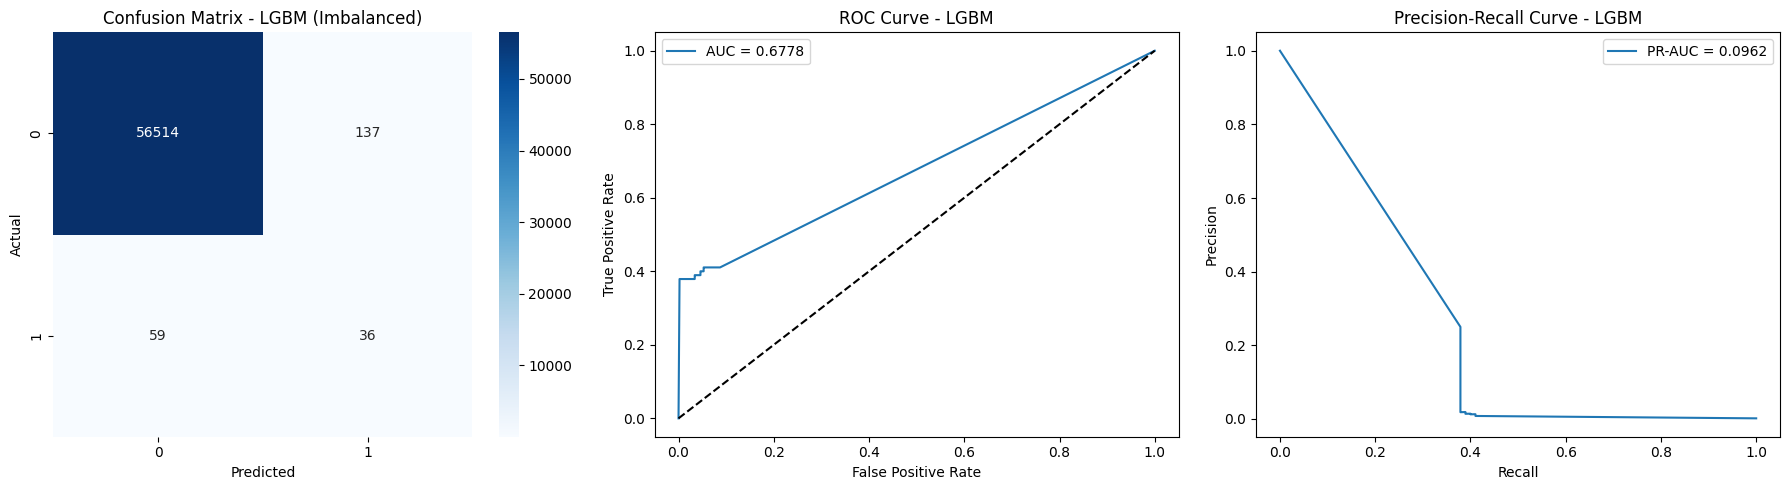

In [7]:
print("=========== LIGHTGBM ===========\n")
print("---> Đang huấn luyện LightGBM trên Dữ liệu Không Cân Bằng <---")
lgb_model = lgb.LGBMClassifier(random_state=42)

start_time = time.time()
lgb_model.fit(X_train, y_train)
train_time = time.time() - start_time

y_pred = lgb_model.predict(X_test)
y_prob = lgb_model.predict_proba(X_test)[:, 1]

print(f"Training Time : {train_time:.2f} s")
print(f"Accuracy      : {accuracy_score(y_test, y_pred):.5f}")
print(f"Precision     : {precision_score(y_test, y_pred):.5f}")
print(f"Recall        : {recall_score(y_test, y_pred):.5f}")
print(f"F1-Score      : {f1_score(y_test, y_pred):.5f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, y_prob):.5f}")
print(f"PR-AUC        : {average_precision_score(y_test, y_prob):.5f}\n")

# Lưu kết quả
global_results.append({
    'Model': 'LightGBM',
    'Method': 'Imbalanced',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1-Score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_prob),
    'PR-AUC': average_precision_score(y_test, y_prob),
    'Train_Time': train_time
})

# Plot CM, ROC, PR
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix - LGBM (Imbalanced)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.4f}")
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('ROC Curve - LGBM')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[2].plot(rec, prec, label=f"PR-AUC = {average_precision_score(y_test, y_prob):.4f}")
axes[2].set_title('Precision-Recall Curve - LGBM')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].legend()
plt.tight_layout()
plt.show()


### 7. Tổng hợp Kết quả Đánh giá

In [8]:
results_df = pd.DataFrame(global_results)
display(results_df.sort_values(by=['Model', 'F1-Score'], ascending=[True, False]))

,Model,Method,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Train_Time
2,LightGBM,Imbalanced,0.996546,0.208092,0.378947,0.268657,0.677803,0.096209,2.790091
0,Random Forest,Imbalanced,0.999542,0.985915,0.736842,0.843373,0.924379,0.797982,35.383323
1,XGBoost,Imbalanced,0.999260,0.811765,0.726316,0.766667,0.934026,0.745339,1.103924


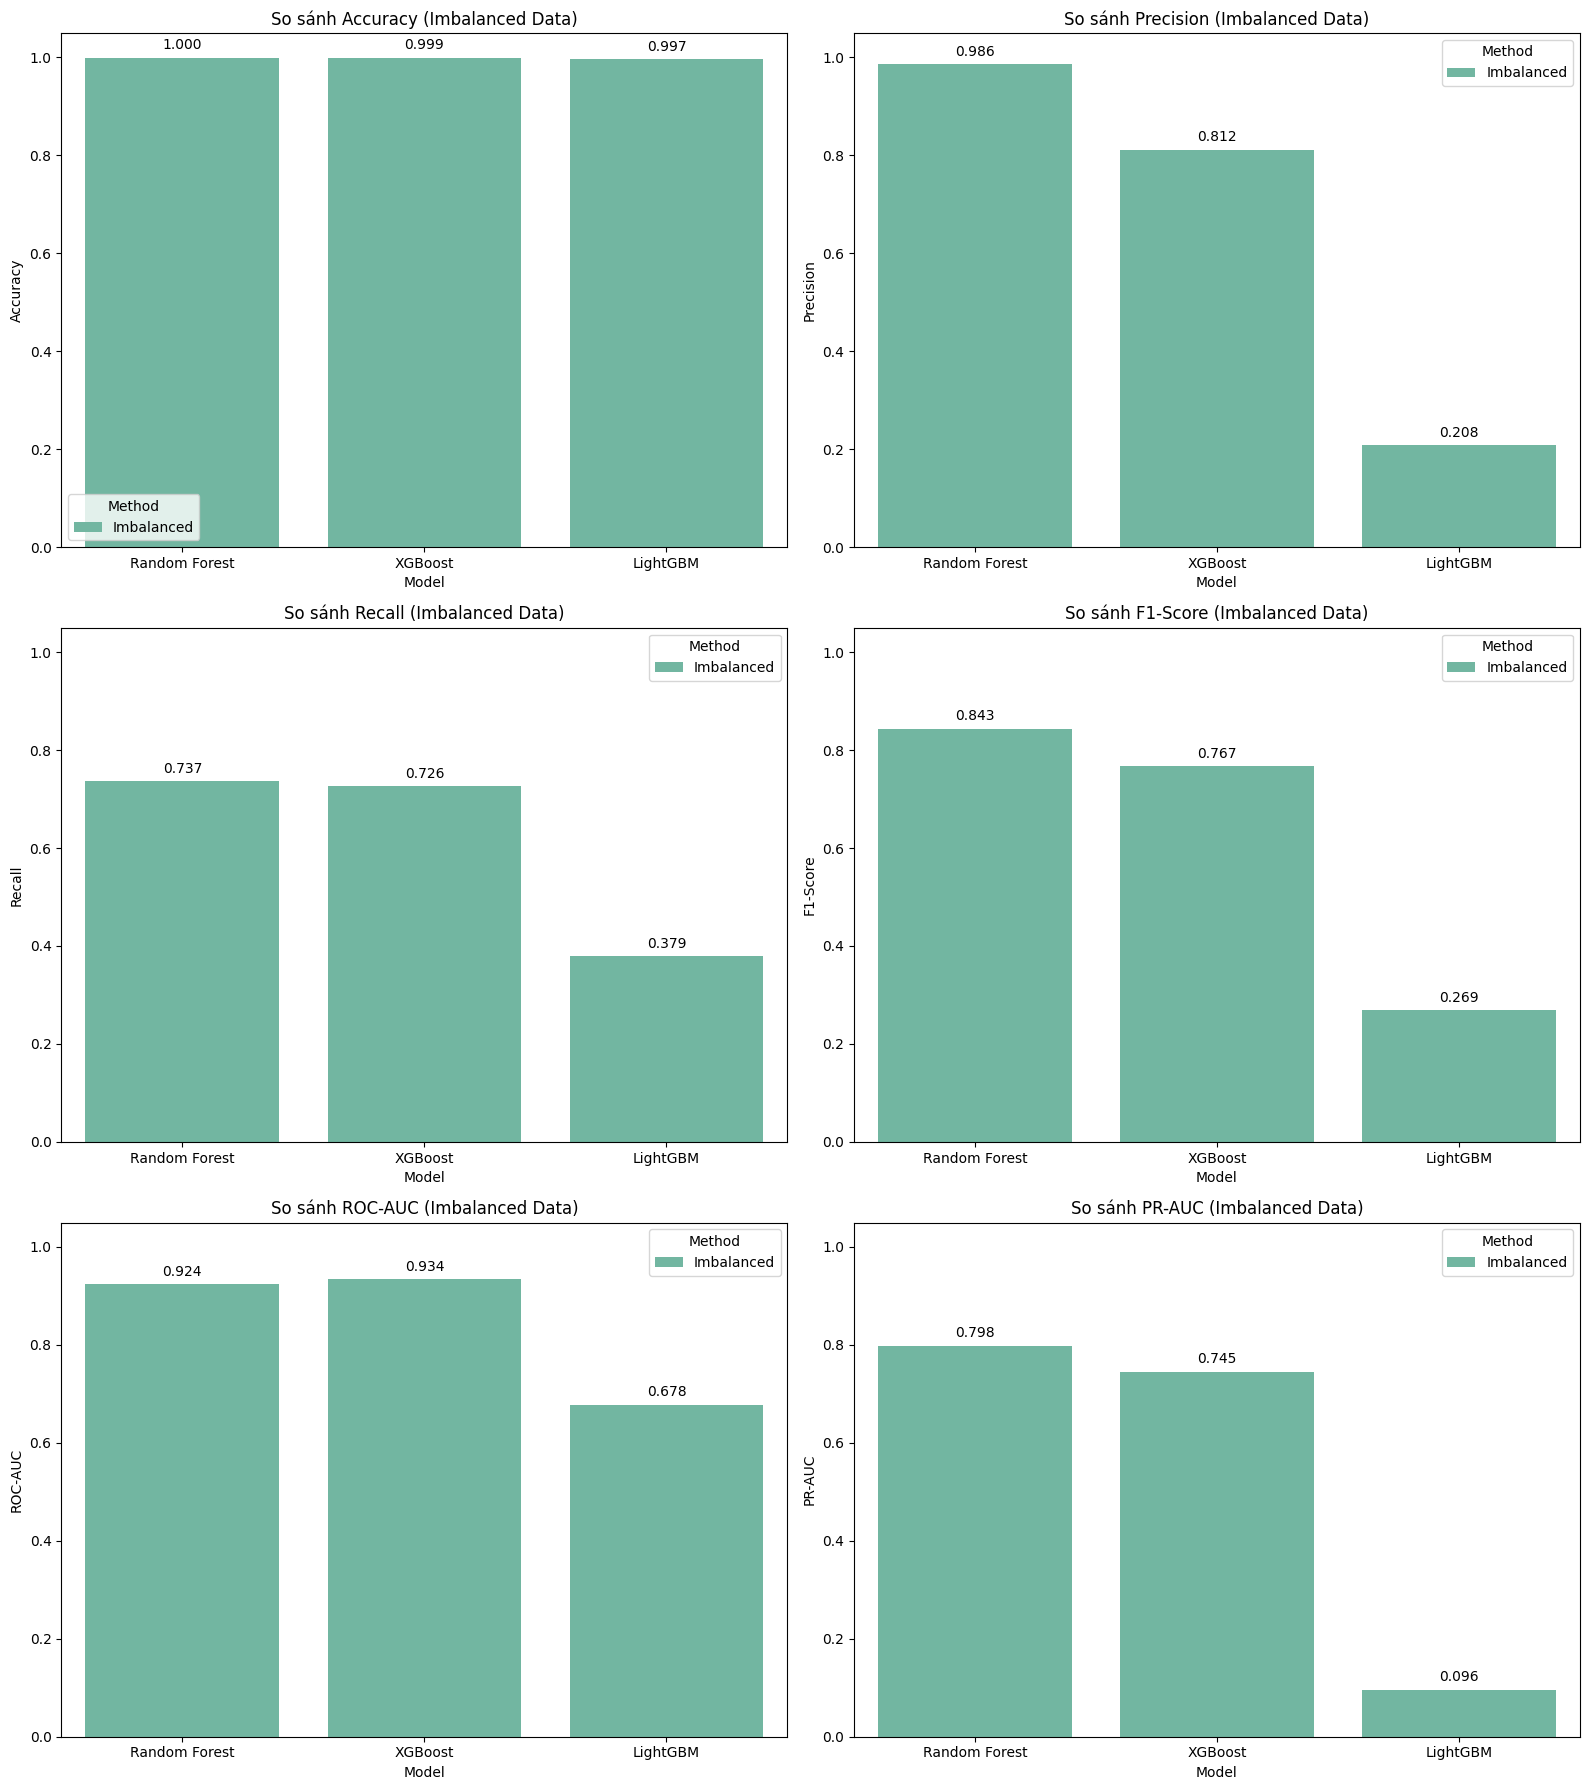

In [9]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(data=results_df, x='Model', y=metric, hue='Method', ax=axes[i], palette='Set2')
    axes[i].set_title(f'So sánh {metric} (Imbalanced Data)')
    axes[i].set_ylim(0, 1.05)
    
    # Add numbers on top of bars
    for p in axes[i].patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            axes[i].annotate(format(height, '.3f'), 
                             (p.get_x() + p.get_width() / 2., height), 
                             ha = 'center', va = 'center', 
                             xytext = (0, 9), 
                             textcoords = 'offset points')

plt.tight_layout()
plt.show()